# Neutrino rates from a collider ring

Event rates at a forward detector fed by the 10 TeV muon-collider ring
(`mc_10tev_hybrid_v06`), and how much of the answer depends on the beam optics.

1. **Lattice variants** -- the nominal ring, one with the chicanes removed, and a
   fully straightened lattice, all built from the same MAD-X TFS table. Useful
   for separating what the geometry does from what the optics do.
2. **Radial event rates** -- $dN/d\rho$ at the detector face, with and without
   beam dynamics, for each variant.
3. **Energy spectra** -- all four neutrino flavors from the $\mu^+$ and $\mu^-$
   beams, with Monte Carlo uncertainty bands.
4. **Context** -- $E\,dN/dE$ against the fluxes of past and planned neutrino
   experiments.
5. **Placement** -- the interaction rate as the detector moves from 250 m to
   50 km, compared against Gaussian approximations to the beam divergence.

The detector used throughout is `mint.detectors.benchmark`; see
`benchmark_detector.ipynb` for what it contains.


In [1]:
%load_ext autoreload
%autoreload 2

import os
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import pandas as pd
import vector

import DarkNews
import mint
mint.xsecs.use_backend("alfonso")   # tabulated cross sections; the
# normalization used throughout MINT. The "ct18" backend recomputes these
# at LO from CT18NNLO PDFs and runs 10-15% lower in CC; see notebook 0.
from mint import lattice_tools, const, xsecs
from mint import plot_tools as pt
from mint.MuC import MuDecaySimulator

os.makedirs("plots", exist_ok=True)

## 1. Lattices

The nominal collider ring is loaded by name from the lattices shipped with MINT. The two
variants (no chicanes / fully straight) are built from the same TFS table: the dataframe
is read with `mint.lattices.read_tfs`, the bending angles are edited, and the modified
table is smoothed into a `Lattice` with the same settings and operational beam parameters
as the nominal ring.

In [2]:
ring = mint.lattices.load("mc_10tev_hybrid_v06")

print(f"Lattice: {ring.name}")
print(f"Circumference: {ring.s(1) / 1e5:.3f} km")
print(f"Beam momentum: {float(ring.beam_p0(0.5)):.0f} GeV")
print(f"Muons per bunch: {ring.Nmu_per_bunch:.1e}")
print(f"Machine circumference: {ring.total_circumference / 1e5:.1f} km "
      f"(lattice covers {ring.s(1) / ring.total_circumference:.1%})")

Lattice: mc_10tev_hybrid_v06
Circumference: 1.465 km
Beam momentum: 5000 GeV
Muons per bunch: 2.0e+12
Machine circumference: 10.0 km (lattice covers 14.6%)


In [3]:
ring_df = mint.lattices.read_tfs("mc_10tev_hybrid_v06")


def make_straight_lattice_from_midpoint(df):
    """Straight-line lattice: zero the first 3 bends on each side of the IP and
    truncate the lattice at the next bend."""
    n = len(df)
    mid = n // 2

    def traverse(start, stop, step):
        out = []
        nonzero_count = 0
        for i in range(start, stop, step):
            row = df.iloc[i].copy()
            if row["ANGLE"] != 0:
                if nonzero_count < 3:
                    row["ANGLE"] = 0
                    nonzero_count += 1
                else:
                    break
            out.append(row)
        return out

    left = traverse(mid, -1, -1)
    right = traverse(mid + 1, n, 1)
    new_df = pd.DataFrame(list(reversed(left)) + right).reset_index(drop=True)
    new_df["ANGLE"] = 0
    new_df["px"] = np.sqrt(new_df["px"] ** 2 + new_df["py"] ** 2)
    new_df["py"] = 0.0
    new_df.attrs = df.attrs.copy()
    return new_df


def make_curved_lattice_with_zero_chicanes(df):
    """Curved lattice with the chicanes removed: zero the first 3 bends on each
    side of the IP, keep the rest of the ring."""
    n = len(df)
    mid = n // 2

    def traverse(start, stop, step):
        out = []
        nonzero_count = 0
        for i in range(start, stop, step):
            row = df.iloc[i].copy()
            if row["ANGLE"] != 0 and nonzero_count < 3:
                row["ANGLE"] = 0
                nonzero_count += 1
            out.append(row)
        return out

    left = traverse(mid, -1, -1)
    right = traverse(mid + 1, n, 1)
    new_df = pd.DataFrame(list(reversed(left)) + right).reset_index(drop=True)
    new_df.attrs = df.attrs.copy()
    return new_df


def lattice_from_df(df, name):
    """Smooth a (modified) TFS dataframe into a Lattice with the same settings
    and operational beam parameters as the nominal ring."""
    lattice_dict = lattice_tools.create_smoothed_lattice(
        df,
        emittance_RMS=mint.lattices.REGISTRY["mc_10tev_hybrid_v06"]["emittance_RMS"],
        n_elements=120_000,
        rotated=True,
        midpoint=True,
        if_sublattice=False,
    )
    lattice = lattice_tools.Lattice(**lattice_dict)
    lattice.name = name
    lattice.short_name = name
    for key in ("Nmu_per_bunch", "finj", "bunch_multiplicity",
                "duty_factor", "total_circumference"):
        setattr(lattice, key, getattr(ring, key))
    return lattice


lattices = {
    "ring": ring,
    "no_chicane": lattice_from_df(make_curved_lattice_with_zero_chicanes(ring_df), "no_chicane_lattice"),
    "straight": lattice_from_df(make_straight_lattice_from_midpoint(ring_df), "straightened_lattice"),
}

for name, lat in lattices.items():
    print(f"{name}: {lat.s(1) * 1e-5:.3f} km covered")

ring: 1.465 km covered
no_chicane: 1.465 km covered
straight: 0.912 km covered


## 2. Simulate the forward neutrino flux

**vegas runs only once.** One run generates the master rest-frame decay sample
($\bar\nu_\mu$, $P = 0$); every other case is an *exact matrix-element reweighting* of the
same sample (`reweighted_copy`). Lattice placement is redone per (lattice, flavor, BD)
combination:

- $\bar\nu_\mu$, $\nu_e$ from the $\mu^+$ beam (clockwise), detector 1 km downstream;
- $\nu_\mu$, $\bar\nu_e$ from the $\mu^-$ beam (counter-clockwise), detector 1 km upstream;
- "no BD" copies are placed with beam dynamics disabled;
- the no-chicane and straight lattices carry only the $\bar\nu_\mu$ cases.

`cycles="full_injection"` simulates one injection period ($1/f_{\rm inj}$ seconds), with
the number of 10 km machine turns computed from `ring.total_circumference`.

In [4]:
N_EVALS = 1e7   # MC statistics

In [5]:
sim_base = MuDecaySimulator(
    muon_polarization=0.0,
    nuflavor="numubar",
    lattice=ring,
    cycles="full_injection",
    n_evals=N_EVALS,
    beam_dynamics=True,
)
print(f"machine turns per injection period: {sim_base.cycles:.0f}")
sim_base.decay_muons()
print(f"vegas sample generated: {sim_base.sample_size} events")


def placed_copy(lattice, nuflavor, direction, beam_dynamics):
    """Reweighted copy of the master sample, placed on the given lattice."""
    sim = sim_base.reweighted_copy(nuflavor=nuflavor)
    sim.beam_dynamics = beam_dynamics
    sim.place_muons_on_lattice(lattice=lattice, direction=direction)
    return sim


beam_direction = {"numubar": "clockwise", "nue": "clockwise",
                  "numu": "counter-clockwise", "nuebar": "counter-clockwise"}

sims = {name: {} for name in lattices}
for flavor in ["numubar", "nue", "numu", "nuebar"]:
    sims["ring"][flavor] = placed_copy(ring, flavor, beam_direction[flavor], True)
sims["ring"]["numubar_nobd"] = placed_copy(ring, "numubar", "clockwise", False)

for name in ["no_chicane", "straight"]:
    sims[name]["numubar"] = placed_copy(lattices[name], "numubar", "clockwise", True)
    sims[name]["numubar_nobd"] = placed_copy(lattices[name], "numubar", "clockwise", False)

for name in sims:
    print(f"placed on {name}: {list(sims[name])}")

machine turns per injection period: 5996


vegas sample generated: 9004503 events


/Users/mhostert/Repos/MINT/mint/MuC.py:491: UserWarning: The lattice covers only 14.6% of the machine (arc length 1.465e+05 cm of total_circumference 1e+06 cm). Muon decays are placed on the covered section only; muon travel times account for propagation through the full machine.
  warnings.warn(


/Users/mhostert/Repos/MINT/mint/MuC.py:491: UserWarning: The lattice covers only 9.1% of the machine (arc length 9.119e+04 cm of total_circumference 1e+06 cm). Muon decays are placed on the covered section only; muon travel times account for propagation through the full machine.
  warnings.warn(


placed on ring: ['numubar', 'nue', 'numu', 'nuebar', 'numubar_nobd']
placed on no_chicane: ['numubar', 'numubar_nobd']
placed on straight: ['numubar', 'numubar_nobd']


### Detector configuration

A forward detector of 2 m radius, 1 km from the IP, modeled as a 10 m column of material
with density 1 g/cm$^3$ (nucleon column density sets the interaction probability). The
$\mu^+$-beam neutrinos are scored 1 km downstream, the $\mu^-$-beam ones 1 km upstream.

In [6]:
# The BENCHMARK detector of the physics studies (physics_studies/): a 10 m x
# 4 m high-pressure GAr TPC with 3 x 5 cm tungsten production slabs, front face
# 5 km from the IP.  
det = mint.detectors.load("benchmark_5km")
print(det)

det_radius = det.radius                          # cm
detector_length_cm = det.fiducial_length         # cm of active gas
nucleon_column_density = det.nucleon_column()      # nucleons / cm^2
detector_area_cm2 = np.pi * det_radius**2

det_location = np.array([0.0, 0.0, det.dist])            # mu+ beam, downstream
det_location_upstream = np.array([0.0, 0.0, -det.dist])  # mu- beam, upstream
L_KM = det.dist / 1e5

# mrad subtended per metre of transverse offset at the detector face
MRAD_PER_M = 1e2 / det.dist * 1e3

bunches_per_year = mint.beams.injections_per_year(ring)

energy_edges = np.linspace(0, 5e3, 41)
energy_centers = 0.5 * (energy_edges[1:] + energy_edges[:-1])
R_MAX_M = 20.0                                    # radial range of the dN/dr plots
r_edges = np.linspace(0.0, R_MAX_M * 1e2, 200)   # cm
r_centers = 0.5 * (r_edges[1:] + r_edges[:-1])

labels = {"numubar": r"$\bar\nu_\mu$", "nue": r"$\nu_e$",
          "numu": r"$\nu_\mu$", "nuebar": r"$\bar\nu_e$"}


def det_loc_for(flavor):
    """mu+ -beam flavors are scored downstream, mu- -beam ones upstream."""
    return (det_location_upstream
            if flavor.replace("_nobd", "") in ("numu", "nuebar")
            else det_location)


print(f"baseline: {L_KM:.0f} km | radius {det_radius/100:.0f} m | "
      f"nucleon column {nucleon_column_density:.3e} /cm^2 "
      f"({nucleon_column_density * 1.66054e-24:.0f} g/cm^2)")
print(f"Bunch crossings per year: {bunches_per_year:.2e}")


Detector('benchmark_5km': 75.5 m long, R = 1.28-2.41 m, 38 m of 5 bar Ar, vertex tracker 24x5 cm r<50 cm at 5.00 km)
baseline: 5 km | radius 1 m | nucleon column 2.593e+25 /cm^2 (43 g/cm^2)
Bunch crossings per year: 5.02e+07


### Event-based helpers

All event-rate observables share the same geometry: the radial distance of each neutrino
ray to the detector axis, and per-event weights folded with the total cross section and
the nucleon column density.

In [7]:
def _accepted_events(sim, det_loc):
    """Radial distance to the detector axis, energy, and MC weight of the
    forward-going events."""
    det_vector = vector.array({"x": det_loc[0], "y": det_loc[1], "z": det_loc[2]})
    distances = det_vector - sim.pos
    neutrino_direction = sim.pnu.to_3D().unit()
    sintheta = np.sqrt(1 - distances.unit().dot(neutrino_direction) ** 2)
    radial_distance = sintheta * distances.mag
    in_acceptance = (distances.dot(neutrino_direction) > 0) & (sim.pnu["E"] > 0)
    return (radial_distance[in_acceptance],
            sim.pnu["E"][in_acceptance],
            sim.weights.flatten()[in_acceptance])


def _event_weights(E, w, flavor):
    """Interacting-neutrino weights [events / year] for the standard detector."""
    sigma = xsecs.total_xsecs[flavor.replace("_nobd", "")](E)
    return w * sigma * nucleon_column_density * bunches_per_year


def event_rate_vs_radius(sim, flavor, r_edges, det_loc):
    """dN/dr of interacting neutrinos [events / year / m], with its MC
    uncertainty (sqrt of the sum of squared weights per bin)."""
    r, E, w = _accepted_events(sim, det_loc)
    event_weights = _event_weights(E, w, flavor)
    counts, _ = np.histogram(r, bins=r_edges, weights=event_weights)
    counts_sq, _ = np.histogram(r, bins=r_edges, weights=event_weights**2)
    dr_m = np.diff(np.asarray(r_edges)) / 100.0   # bins are in cm
    return counts / dr_m, np.sqrt(counts_sq) / dr_m


def flux_vs_radius(sim, r_edges, det_loc):
    """Areal neutrino flux density dPhi/dA [nu / cm^2 / year] vs the radial
    distance from the detector axis, with its MC uncertainty.

    Unlike event_rate_vs_radius this involves NO cross section and NO target,
    so it is a property of the beam alone -- the quantity a detector of any
    material would see."""
    r, _E, w = _accepted_events(sim, det_loc)
    nu_per_year = w * bunches_per_year
    counts, _ = np.histogram(r, bins=r_edges, weights=nu_per_year)
    counts_sq, _ = np.histogram(r, bins=r_edges, weights=nu_per_year**2)
    edges = np.asarray(r_edges)
    annulus_cm2 = np.pi * (edges[1:] ** 2 - edges[:-1] ** 2)
    return counts / annulus_cm2, np.sqrt(counts_sq) / annulus_cm2


def E_vs_radius_event_map(sim, flavor, det_loc, ebins, r_edges):
    """2D histogram (radius, energy) of interacting-neutrino weights [events/yr/bin]."""
    r, E, w = _accepted_events(sim, det_loc)
    event_weights = _event_weights(E, w, flavor)
    return np.histogram2d(r, E, bins=[r_edges, ebins], weights=event_weights)


def event_rate_uncertainty_vs_energy(sim, flavor, ebins, det_loc):
    """MC uncertainty of the event rate per energy bin, for neutrinos crossing
    the detector z-plane within det_radius of the axis."""
    z_det = det_loc[2]
    t = (z_det - sim.pos["z"]) / sim.pnu["pz"]
    x_hit = sim.pos["x"] + t * sim.pnu["px"]
    y_hit = sim.pos["y"] + t * sim.pnu["py"]
    det_vector = vector.array({"x": det_loc[0], "y": det_loc[1], "z": det_loc[2]})
    dotprod = (det_vector - sim.pos).dot(sim.pnu.to_3D().unit())
    in_acceptance = ((dotprod > 0) & (sim.pnu["E"] > 0)
                     & (np.sqrt(x_hit**2 + y_hit**2) < det_radius))
    event_weights = _event_weights(sim.pnu["E"][in_acceptance],
                                   sim.weights.flatten()[in_acceptance], flavor)
    sum_w_sq, _ = np.histogram(sim.pnu["E"][in_acceptance], bins=ebins,
                               weights=event_weights**2)
    return np.sqrt(sum_w_sq)

## 3. Radial event rates

$dN/d\rho$ of interacting neutrinos vs radial distance from the detector axis, for all
lattice variants, with and without beam dynamics.

In [8]:
radial = {}   # radial[(lattice, flavor)] = (dN/dr [events/yr/m], MC uncertainty)
for lat in sims:
    for flavor in sims[lat]:
        radial[(lat, flavor)] = event_rate_vs_radius(
            sims[lat][flavor], flavor, r_edges, det_loc_for(flavor)
        )

radial_flux = {}   # radial_flux[(lattice, flavor)] = (dPhi/dA [nu/cm^2/yr], MC unc.)
for lat in sims:
    for flavor in sims[lat]:
        radial_flux[(lat, flavor)] = flux_vs_radius(
            sims[lat][flavor], r_edges, det_loc_for(flavor)
        )
print("computed:", list(radial))

computed: [('ring', 'numubar'), ('ring', 'nue'), ('ring', 'numu'), ('ring', 'nuebar'), ('ring', 'numubar_nobd'), ('no_chicane', 'numubar'), ('no_chicane', 'numubar_nobd'), ('straight', 'numubar'), ('straight', 'numubar_nobd')]


Peak dPhi/dr: 1.918e+18 nu/yr/m
Relative MC uncertainty: 10.11%
Integrated over the 1 m face: 1.836e+18 nu/yr


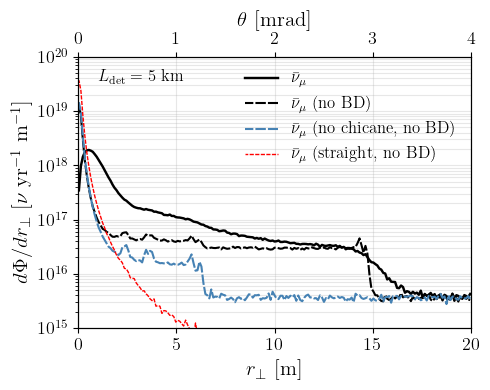

In [9]:
annulus_area_cm2 = np.pi * np.diff(r_edges**2)
dr_m = np.diff(r_edges) / 100.0

def area_flux_to_dphi_dr(phi_area, err_area=None):
    """Convert dPhi/dA [nu/cm^2/yr] to dPhi/dr [nu/yr/m]."""
    scale = annulus_area_cm2 / dr_m
    dphi_dr = phi_area * scale
    if err_area is None:
        return dphi_dr
    return dphi_dr, err_area * scale


radial_flux_dr = {}
for key, (phi_area, err_area) in radial_flux.items():
    radial_flux_dr[key] = area_flux_to_dphi_dr(phi_area, err_area)


fig, ax = plt.subplots(figsize=(5, 4))

dphi_dr_numubar, err_dr_numubar = radial_flux_dr[("ring", "numubar")]

ax.plot(
    r_centers / 100.0,
    dphi_dr_numubar,
    lw=1.75,
    label=labels["numubar"],
    color="black",
)

ax.plot(
    r_centers / 100.0,
    radial_flux_dr[("ring", "numubar_nobd")][0],
    lw=1.5,
    ls=(1, (5, 1)),
    label=labels["numubar"] + r" (no BD)",
    color="black",
)

ax.plot(
    r_centers / 100.0,
    radial_flux_dr[("no_chicane", "numubar_nobd")][0],
    lw=1.5,
    ls=(1, (5, 1)),
    label=labels["numubar"] + " (no chicane, no BD)",
    color="steelblue",
)

ax.plot(
    r_centers / 100.0,
    radial_flux_dr[("straight", "numubar_nobd")][0],
    lw=1.0,
    ls=(1, (3, 1)),
    label=labels["numubar"] + " (straight, no BD)",
    color="red",
)

print(f"Peak dPhi/dr: {dphi_dr_numubar.max():.3e} nu/yr/m")
print(
    "Relative MC uncertainty: "
    f"{(err_dr_numubar / np.maximum(dphi_dr_numubar, 1e-300)).max():.2%}"
)

inside = r_centers < det_radius
phi_face = np.sum(dphi_dr_numubar[inside] * dr_m[inside])
print(
    f"Integrated over the {det_radius/100:.0f} m face: {phi_face:.3e} nu/yr"
)

ax2 = ax.twiny()
ax2.set_xlim(0, R_MAX_M * MRAD_PER_M)
ax2.set_xlabel(r"$\theta$ [mrad]", fontsize=15)

ax.tick_params(axis="both", labelsize=13)
ax2.tick_params(axis="both", labelsize=13)

ax.set_xlabel(r"$r_\perp$ [m]", fontsize=15)
ax.set_ylabel(r"$d\Phi/dr_\perp$ [$\nu\ {\rm yr}^{-1}\ {\rm m}^{-1}$]", fontsize=15)

ax.set_xlim(0, R_MAX_M)
ax.set_ylim(1e15, 1e20)
ax.set_yscale("log")
ax.grid(True, which="both", ls="-", alpha=0.3)

ax.set_xticks(np.arange(0, R_MAX_M + 1, 5))
ax.legend(frameon=False, fontsize=12)

ax.annotate(
    rf"$L_{{\rm det}} = {L_KM:.0f}$ km",
    xy=(0.05, 0.95),
    xycoords="axes fraction",
    fontsize=12,
    verticalalignment="top",
)

fig.tight_layout()
fig.savefig("plots/flux_radial_dPhi_dr.pdf", dpi=300, bbox_inches="tight")

/var/folders/dl/ccbsfs591r1fhgcws28m8xy40000gn/T/ipykernel_70858/2260270723.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


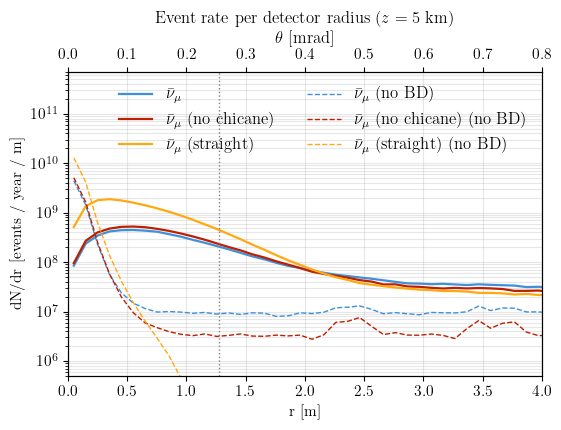

In [10]:
fig, ax = pt.std_fig(figsize=(6, 4))

for lat, tag in [("ring", ""), ("no_chicane", " (no chicane)"), ("straight", " (straight)")]:
    ax.plot(r_centers / 100.0, radial[(lat, "numubar")][0], lw=1.6,
            label=labels["numubar"] + tag)

plt.gca().set_prop_cycle(None)
for lat in ["ring", "no_chicane", "straight"]:
    dN_dr, err = radial[(lat, "numubar")]
    ax.fill_between(r_centers / 100.0, dN_dr - err, dN_dr + err, alpha=0.3)

for lat, tag in [("ring", ""), ("no_chicane", " (no chicane)"), ("straight", " (straight)")]:
    ax.plot(r_centers / 100.0, radial[(lat, "numubar_nobd")][0], lw=1.0, ls="--",
            label=labels["numubar"] + tag + r" (no BD)")

ax2 = ax.twiny()
ax2.set_xlim(0, 4 * MRAD_PER_M)   # theta ~ rho / L_det
ax2.set_xlabel(r"$\theta$ [mrad]", fontsize=12)

ax.set_xlabel("r [m]")
ax.set_ylabel("dN/dr [events / year / m]")
ax.set_xlim(0, 4)
ax.grid(True, which="both", ls="-", alpha=0.3)
ax.set_ylim(5e5, 7e11)
ax.set_yscale("log")
ax.legend(frameon=False, fontsize=12, ncol=2)
ax.axvline(det_radius / 100, color="gray", ls=":", lw=1.0)
ax.set_title(rf"Event rate per detector radius ($z = {L_KM:.0f}$ km)")
fig.tight_layout()
fig.savefig("plots/hybrid_v06_event_rate_radial(4m).pdf", dpi=300, bbox_inches="tight")

## 4. Event-rate energy spectrum

Interactions per year in the forward detector for all four flavors, folding the flux with
the total neutrino-nucleon cross section. Bands are $\pm 2\sigma$ MC uncertainties.

/var/folders/dl/ccbsfs591r1fhgcws28m8xy40000gn/T/ipykernel_70858/4101626644.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Estimated total forward event rate (numubar): 4.214e+08 events/year
Estimated total forward event rate (nue): 6.034e+08 events/year
Estimated total forward event rate (numu): 6.944e+08 events/year
Estimated total forward event rate (nuebar): 3.620e+08 events/year


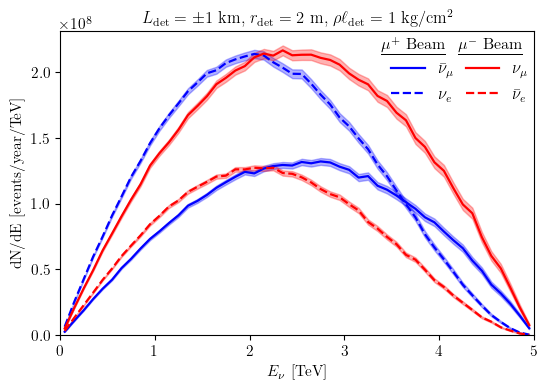

In [11]:
GeV_to_TeV = 1e-3
TeV_to_GeV = 1e3
energy_edges = np.linspace(0, 5e3, 51)
energy_centers = 0.5 * (energy_edges[1:] + energy_edges[:-1])

# Flux through the detector face [nu / cm^2 / GeV / year] and event-rate spectrum
fluxes, event_rates = {}, {}
for flavor, sim in sims["ring"].items():
    _, flux = sim.get_flux_at_generic_location(
        det_location=det_loc_for(flavor),
        det_radius=det_radius,
        ebins=energy_edges,
        per_cm2=True,
        normalization=bunches_per_year,
    )
    fluxes[flavor] = flux
    sigma_tot = xsecs.total_xsecs[flavor.replace("_nobd", "")](energy_centers)
    event_rates[flavor] = flux * detector_area_cm2 * sigma_tot * nucleon_column_density

mc_uncertainties = {
    flavor: event_rate_uncertainty_vs_energy(
        sims["ring"][flavor], flavor, energy_edges, det_loc_for(flavor)
    )
    for flavor in ["numubar", "nue", "numu", "nuebar"]
}

fig, ax = pt.std_fig(figsize=(6, 4))
colors = {"numubar": "blue", "nue": "blue", "numu": "red", "nuebar": "red"}
ls = {"numubar": "-", "nue": "--", "numu": "-", "nuebar": "--"}
dE = np.diff(energy_edges)

for flavor in ["numubar", "nue", "numu", "nuebar"]:
    dN_dE = event_rates[flavor]
    band = 2 * mc_uncertainties[flavor] / dE
    ax.plot(energy_centers * GeV_to_TeV, dN_dE / GeV_to_TeV, lw=1.6,
            label=labels[flavor], color=colors[flavor], ls=ls[flavor])
    ax.fill_between(energy_centers * GeV_to_TeV, (dN_dE - band) / GeV_to_TeV,
                    (dN_dE + band) / GeV_to_TeV, color=colors[flavor], alpha=0.3)

ax.set_xlabel(r"$E_\nu$ [TeV]")
ax.set_ylabel(r"dN/dE [events/year/TeV]")
ax.set_xlim(0, 5)
ax.set_ylim(0, None)

ax.text(0.745, 0.982, r"$\underline{\mu^+ \text{ Beam}}$", transform=ax.transAxes,
        fontsize=11.5, ha="center", va="top")
ax.text(0.907, 0.982, r"$\underline{\mu^- \text{ Beam}}$", transform=ax.transAxes,
        fontsize=11.5, ha="center", va="top")
ax.legend(frameon=False, fontsize=12, ncol=2, loc=(0.685, 0.745), columnspacing=0.75)
ax.set_title(r"$L_{\rm det} = \pm 1$ km, $r_{\rm det} = 2$ m, $\rho \ell_{\rm det} = 1$ kg/cm$^2$", fontsize=12)
fig.tight_layout()

for flavor in ["numubar", "nue", "numu", "nuebar"]:
    total = np.trapezoid(event_rates[flavor], energy_centers)
    print(f"Estimated total forward event rate ({flavor}): {total:.3e} events/year")

fig.savefig("plots/hybrid_v06_event_rate_spectrum.pdf", dpi=300, bbox_inches="tight")

cross-section backend: alfonso
mu+ beam: CC events/yr (both flavors) = 7.960e+08
mu- beam: CC events/yr (both flavors) = 8.229e+08


/var/folders/dl/ccbsfs591r1fhgcws28m8xy40000gn/T/ipykernel_70858/2901919553.py:134: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


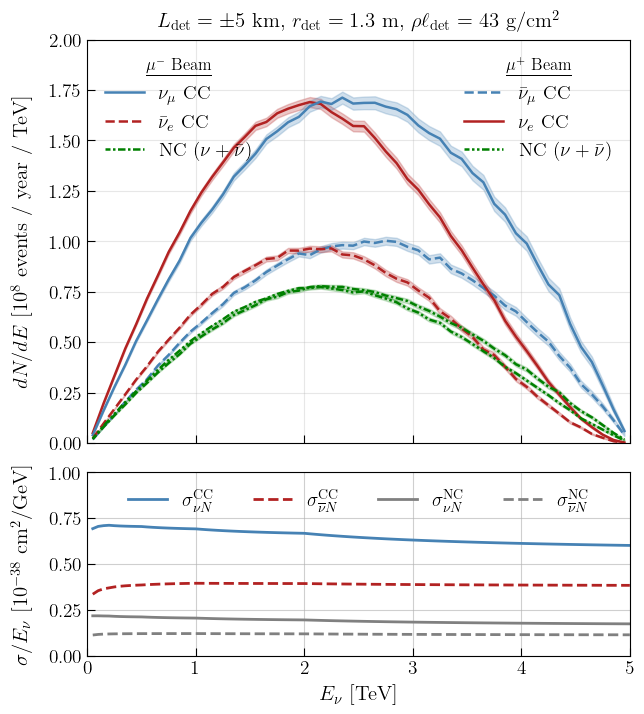

In [12]:
# Cross sections: MINT's own LO calculation with CT18NNLO PDFs
# (mint.xsecs.use_backend("alfonso"), selected in the setup cell) -- the same
# backend and the same conventions as the physics_studies studies:
#   * CC total per nucleon from xsecs.sigma_CC (light + charm + bottom),
#   * a real NC calculation (chiral couplings + Z propagator),
#   * the NON-ISOSCALAR correction of the benchmark column: the detector is
#     94.6% tungsten (Z/A = 0.402), which enhances nu CC by ~5% and suppresses
#     nubar CC by ~4%.  (The NC asymmetry is much smaller and is neglected,
#     as in notebook 0.)
print("cross-section backend:", xsecs.current_backend())

xsec_nc = {"numu": xsecs.sigma_NC_nu, "nue": xsecs.sigma_NC_nu,
           "numubar": xsecs.sigma_NC_nubar, "nuebar": xsecs.sigma_NC_nubar}

units = 1e-8

fig, (ax_rate, ax_xsec) = plt.subplots(
    2, 1, sharex=True, figsize=(7, 8),
    gridspec_kw={"height_ratios": [2.2, 1], "hspace": 0.1}
)

colors = {"numubar": "steelblue", "nue": "firebrick", "numu": "steelblue", "nuebar": "firebrick"}
ls = {"numubar": "--", "nue": "-", "numu": "-", "nuebar": "--"}
dE = np.diff(energy_edges)
E_TeV = energy_centers * GeV_to_TeV

# Top panel: CC event-rate spectrum per flavor. The MC band (computed with the
# total cross section) is rescaled by the CC fraction.
event_rates_cc = {}
handles = {}
for flavor in ["numubar", "nue", "numu", "nuebar"]:
    f0 = flavor.replace("_nobd", "")
    # non-isoscalar (W-dominated) column correction, as in physics_studies
    sigma_cc = xsecs.sigma_CC(energy_centers, f0) * det.cc_correction(energy_centers, f0)
    event_rates_cc[flavor] = (
        fluxes[flavor] * detector_area_cm2 * sigma_cc * nucleon_column_density
    )

    dN_dE = event_rates_cc[flavor]  # events / year / GeV
    cc_fraction = sigma_cc / xsecs.total_xsecs[f0](energy_centers)
    band = 2.0 * mc_uncertainties[flavor] / dE * cc_fraction
    (handles[flavor],) = ax_rate.plot(
        E_TeV, dN_dE * units / GeV_to_TeV, lw=1.8,
        color=colors[flavor], ls=ls[flavor], label=labels[flavor] + " CC",
    )
    ax_rate.fill_between(
        E_TeV, (dN_dE - band) * units / GeV_to_TeV, (dN_dE + band) * units / GeV_to_TeV,
        color=colors[flavor], alpha=0.25,
    )

# Dotted: NC event rate summed over the nu + nubar reaching each detector
# (mu+ beam: numubar + nue downstream;  mu- beam: numu + nuebar upstream).
nc_beam_flavors = {"mu+": ("numubar", "nue"), "mu-": ("numu", "nuebar")}
nc_beam_colors = {"mu+": "green", "mu-": "green"}
nc_beam_dash = {"mu+": (1, (3, 1, 1, 1, 1, 1)), "mu-": (1, (3, 1,1,1))}

for beam, flavors in nc_beam_flavors.items():
    nc_rates = []
    nc_bands = []
    for f in flavors:
        sigma_nc_f = xsec_nc[f](energy_centers)
        nc_rate_f = fluxes[f] * detector_area_cm2 * sigma_nc_f * nucleon_column_density
        nc_fraction_f = sigma_nc_f / xsecs.total_xsecs[f](energy_centers)
        nc_band_f = 2.0 * mc_uncertainties[f] / dE * nc_fraction_f
        nc_rates.append(nc_rate_f)
        nc_bands.append(nc_band_f)

    nc_rate = np.sum(nc_rates, axis=0) * units  # 1e9 events / year / GeV
    nc_band = np.sqrt(np.sum([b**2 for b in nc_bands], axis=0)) * units  # independent MC errors

    (handles[f"nc_{beam}"],) = ax_rate.plot(
        E_TeV, nc_rate / GeV_to_TeV, lw=1.8,
        color=nc_beam_colors[beam], ls=nc_beam_dash[beam], label=r"NC ($\nu + \bar\nu$)",
    )
    ax_rate.fill_between(
        E_TeV, (nc_rate - nc_band) / GeV_to_TeV, (nc_rate + nc_band) / GeV_to_TeV,
        color=nc_beam_colors[beam], alpha=0.20,
    )

ax_rate.set_ylabel(r"$dN/dE$ [$10^8$ events / year / TeV]", fontsize=15, labelpad=12)
ax_rate.set_xlim(0.0, 5)
ax_rate.set_ylim(0, 2)
ax_rate.grid(True, which="both", ls="-", alpha=0.3)
ax_rate.tick_params(axis='both', which='major', labelsize=12)
# Column-major legend: [mu+ beam: numubar, nue, NC | mu- beam: numu, nuebar, NC]
legend_order = ["numubar", "nue", "nc_mu+", "numu", "nuebar", "nc_mu-"]
l1 = ax_rate.legend(handles=[handles[k] for k in legend_order[:3]],
               title=r"$\underline{\mu^+ \text{ Beam}}$", title_fontsize=12,
               frameon=False, fontsize=14, ncol=1, loc="upper right")
l2 = ax_rate.legend(handles=[handles[k] for k in legend_order[3:]],
               title=r"$\underline{\mu^- \text{ Beam}}$", title_fontsize=12,
               frameon=False, fontsize=14, ncol=1, loc="upper left")
ax_rate.add_artist(l1)


# Bottom panel: CC and NC cross sections for nu and nubar (isoscalar per nucleon)
E_TeV_xsec = np.linspace(0.05, 5, 100)   # TeV (tables start at 20-50 GeV)
E_GeV_xsec = E_TeV_xsec * TeV_to_GeV

ax_xsec.plot(E_TeV_xsec, xsecs.sigma_CC(E_GeV_xsec, "numu") / E_GeV_xsec * 1e38,
             color="steelblue", lw=2, label=r"$\sigma^{\rm CC}_{\nu N}$")
ax_xsec.plot(E_TeV_xsec, xsecs.sigma_CC(E_GeV_xsec, "numubar") / E_GeV_xsec * 1e38,
             color="firebrick", lw=2, ls="--", label=r"$\sigma^{\rm CC}_{\overline{\nu} N}$")
ax_xsec.plot(E_TeV_xsec, xsecs.sigma_NC_nu(E_GeV_xsec) / E_GeV_xsec * 1e38,
             color="gray", lw=2, label=r"$\sigma^{\rm NC}_{\nu N}$")
ax_xsec.plot(E_TeV_xsec, xsecs.sigma_NC_nubar(E_GeV_xsec) / E_GeV_xsec * 1e38,
             color="gray", lw=2, ls="--", label=r"$\sigma^{\rm NC}_{\overline{\nu} N}$")

ax_xsec.set_xlabel(r"$E_\nu$ [TeV]", fontsize=15)
ax_xsec.set_ylabel(r"$\sigma/E_\nu$ [$10^{-38}$ cm$^2$/GeV]", fontsize=15, labelpad=12)
ax_xsec.set_xlim(0, 5)
ax_xsec.set_ylim(0, 1)
ax_xsec.grid(True, which="both", ls="-", alpha=0.6)
ax_xsec.legend(frameon=False, fontsize=14, ncol=4, loc='upper center')
ax_xsec.tick_params(axis='both', which='major', labelsize=12)
# ax_xsec.annotate("LO CT18NNLO (MINT)", xy=(0.985, 0.06), xycoords="axes fraction",
                #  ha="right", fontsize=10, color="dimgrey")

ax_rate.annotate(
    rf"$L_{{\rm det}} = \pm {L_KM:.0f}$ km, $r_{{\rm det}} = {det_radius/100:.1f}$ m, "
    rf"$\rho \ell_{{\rm det}} = {nucleon_column_density * 1.66054e-24:.0f}$ g/cm$^2$",
    fontsize=15,
    xy=(0.5, 1.02), xycoords="axes fraction", ha="center", va="bottom"
)

for beam, fl in [("mu+", ("numubar", "nue")), ("mu-", ("numu", "nuebar"))]:
    tot_cc = sum(np.sum(event_rates_cc[f] * dE) for f in fl)
    print(f"{beam} beam: CC events/yr (both flavors) = {tot_cc:.3e}")

for ax in [ax_rate, ax_xsec]:
    ax.tick_params(axis='both', which='major', direction='in', labelsize=14, length=6)


fig.tight_layout()
fig.savefig("plots/event_rate_and_xsec.pdf", dpi=300, bbox_inches="tight")


## 5. Comparison with past neutrino experiments

$E\, dN/dE$ of the $\bar\nu_\mu$ and $\nu_e$ event rates against digitized spectra of past
and planned experiments (`data/`).

In [13]:
nu_spectrum_dir = "data"
nu_spectrum = {}
for fname in sorted(os.listdir(nu_spectrum_dir)):
    if fname.endswith(".csv") and fname not in {"PA.csv", "RLA1.csv", "RLA2.csv"}:
        arr = np.genfromtxt(os.path.join(nu_spectrum_dir, fname), delimiter=",")
        nu_spectrum[fname[:-4].replace("_", " ")] = arr[~np.isnan(arr).any(axis=1)]

print("experiments loaded:", list(nu_spectrum))

experiments loaded: ['CDHS', 'CHORUS', 'DUNE ND', 'FASER', 'FPF', 'MuC 10TeV', 'NOMAD', 'NuTeV']


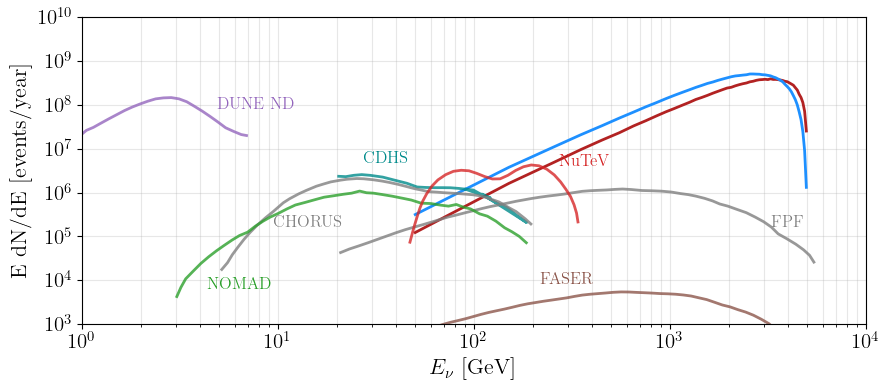

In [14]:
fig, ax = plt.subplots(figsize=(9, 4))

(line_numubar,) = ax.plot(energy_centers, event_rates["numubar"] * energy_centers,
                          lw=2, label=labels["numubar"] + " (Latest Design)", color="firebrick")
(line_nue,) = ax.plot(energy_centers, event_rates["nue"] * energy_centers,
                      lw=2, label=labels["nue"] + " (Latest Design)", color="dodgerblue")
ax.set_xscale("log")
ax.set_yscale("log")

plt.gca().set_prop_cycle(None)

experiment_colors = ["darkcyan", "grey", "tab:purple", "tab:brown", "tab:gray",
                     "tab:pink", "tab:green", "tab:red", "tab:orange",
                     "darkgreen", "indigo", "magenta"]
exp_line_handles = []
for i, (exp_name, arr) in enumerate(nu_spectrum.items()):
    if exp_name == "MuC 10TeV":
        continue
    (exp_line,) = ax.plot(arr[:, 0], arr[:, 1], "-", lw=2, alpha=0.8,
                          color=experiment_colors[i % len(experiment_colors)],
                          label=exp_name)
    exp_line_handles.append((exp_line, exp_name))

ax.set_xlabel(r"$E_\nu$ [GeV]", fontsize=16)
ax.set_ylabel(r"E dN/dE [events/year]", fontsize=16)
ax.set_xlim(1e0, 1e4)
ax.set_ylim(1e3, 1e10)
# ax.set_title(r"$\bar{\nu}_\mu$ Energy Spectrum", fontsize=16)
ax.set_yticks([1e3, 1e4, 1e5, 1e6, 1e7, 1e8, 1e9, 1e10])
ax.tick_params(axis="both", which="major", labelsize=15)
ax.tick_params(axis="both", which="minor", labelsize=12)
ax.grid(True, which="both", ls="-", alpha=0.3)
fig.tight_layout()

manual_label_positions = {
    "CHORUS": (8.7, 2e5),
    "DUNE ND": (4.5, 1e8),
    "NuTeV": (250, 5e6),
    "FPF": (3000, 2e5),
    "NOMAD": (4, 8e3),
    "CDHS": (25, 6e6),
    "FASER": (200, 1e4),
}


def annotate_line(ax, line, text, xy):
    ax.annotate(text, xy=xy, xytext=(5, 0), textcoords="offset points",
                color=line.get_color(), fontsize=12, va="center", ha="left",
                fontweight="bold")


# annotate_line(ax, line_numubar, r"\noindent MuC 10 TeV ($\bar\nu_\mu$)", (1e2, 1e10))
# annotate_line(ax, line_nue, r"\noindent MuC 10 TeV ($\nu_e$)", (16, 1e9))
for exp_line, exp_name in exp_line_handles:
    xy = manual_label_positions.get(
        exp_name, (np.median(exp_line.get_xdata()), np.median(exp_line.get_ydata()))
    )
    annotate_line(ax, exp_line, exp_name, xy)

fig.savefig("plots/numubar_spectrum.pdf", dpi=300, bbox_inches="tight")

### Flux-only comparison, $\nu\,{\rm cm}^{-2}\,{\rm s}^{-1}$

The figure above compares *event rates*, which fold in each detector's target
and cross section. Here we compare the **fluxes** alone — a property of the
beams — against past, current and future facilities, using the flux tables
shipped with `DarkNews` (SBND, DUNE ND, NuTeV, CHARM II, FASER$\nu$).

**Normalisation.** `DarkNews` normalises each flux to that experiment's
*nominal exposure* (`Detector.POTS`; for FASER$\nu$, units of 150 fb$^{-1}$).
Converting to a **rate** therefore requires one external number per facility:
the calendar time over which that exposure is delivered. Those are the only
inputs not computed by MINT, and they are collected in a single editable dict
below. All curves — including the muon collider, whose `duty_factor` = $1/\pi$
already encodes its $\sim10^7$ s of beam per year — are quoted as
**calendar-year-averaged** rates, so they are directly comparable.

MuC numubar : peak E dPhi/dE = 6.193e+05 nu/cm^2/s at E = 2686 GeV | integrated 1.110e+06 nu/cm^2/s


MuC nue     : peak E dPhi/dE = 5.914e+05 nu/cm^2/s at E = 2038 GeV | integrated 1.114e+06 nu/cm^2/s


/var/folders/dl/ccbsfs591r1fhgcws28m8xy40000gn/T/ipykernel_70858/4173135274.py:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


SBND        : peak E dPhi/dE = 6.139e+03 nu/cm^2/s
DUNE ND     : peak E dPhi/dE = 1.058e+05 nu/cm^2/s
NuTeV       : peak E dPhi/dE = 5.209e+00 nu/cm^2/s
CHARM II    : peak E dPhi/dE = 4.427e+02 nu/cm^2/s


FASER$\nu$  : peak E dPhi/dE = 1.461e+02 nu/cm^2/s


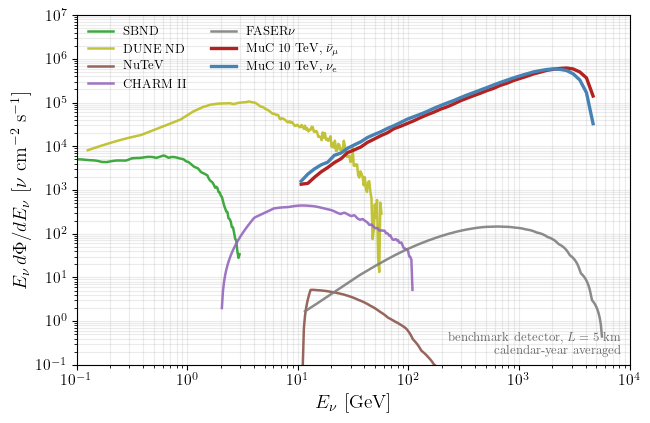

In [15]:
from DarkNews.detector import Detector
from DarkNews import pdg as dn_pdg

S_YEAR = const.s_in_year

# ---------------------------------------------------------------------------
# THE ONLY EXTERNAL ASSUMPTIONS IN THIS FIGURE: the calendar time over which
# each facility delivers the nominal exposure that DarkNews normalises to.
# Edit here to update the comparison.
# ---------------------------------------------------------------------------
YEARS_FOR_NOMINAL_EXPOSURE = {
    "sbnd":        3.0,    # DarkNews 1.56e21 POT of BNB running
    "dune_nd_fhc": 10.0,   # DarkNews 1e22 POT at ~1.1e21 POT/yr (1.2 MW, 120 GeV)
    "nutev_fhc":   1.0,    # DarkNews 5e18 POT, the 1996-97 run
    "fasernu":     3.0,    # 150 fb^-1 = LHC Run 3
}
# CHARM II has a flux file in DarkNews but no detector definition, so its POT
# normalisation must be supplied by hand.  <-- ASSUMPTION, please check.
CHARMII_POT, CHARMII_YEARS = 2.5e19, 4.0   # SPS WANF, 1987-91

EXP_STYLE = {   # label, color
    "sbnd":        (r"SBND",        "tab:green"),
    "dune_nd_fhc": (r"DUNE ND",     "tab:olive"),
    "nutev_fhc":   (r"NuTeV",       "tab:brown"),
    "charmii":     (r"CHARM II",    "tab:purple"),
    "fasernu":     (r"FASER$\nu$",  "tab:gray"),
}

E_cmp = np.geomspace(0.1, 1e4, 500)

def facility_EdPhidE(name):
    """E dPhi/dE [nu / cm^2 / s] of numubar at a DarkNews facility."""
    if name == "charmii":
        a = np.genfromtxt(os.path.join(os.path.dirname(DarkNews.__file__),
                                       "include", "fluxes", "CHARMII_FHC.dat"))
        # file is nu / m^2 / GeV / POT  ->  nu / cm^2 / GeV / POT
        dphi = np.interp(E_cmp, a[:, 0], a[:, 5], left=0.0, right=0.0) * 1e-4
        return dphi * CHARMII_POT / (CHARMII_YEARS * S_YEAR) * E_cmp
    d = Detector(name)
    f = d.neutrino_flux(dn_pdg.numubar)
    dphi = np.nan_to_num(np.asarray(f(E_cmp)), nan=0.0)   # nu/cm^2/GeV/POT
    return dphi * d.POTS / (YEARS_FOR_NOMINAL_EXPOSURE[name] * S_YEAR) * E_cmp


def muc_EdPhidE(flavor, sign=+1, nbins=45):
    """E dPhi/dE [nu / cm^2 / s] through the benchmark detector face.
    Histogrammed from the RAW MC flux (never from a re-binned grid)."""
    E_raw, w_raw = det.face_flux(sims["ring"][flavor], sign=sign,
                                 exposure=bunches_per_year)   # nu / year
    edges = np.geomspace(10.0, 5e3, nbins + 1)
    cnt, _ = np.histogram(E_raw, bins=edges, weights=w_raw)
    ctr = np.sqrt(edges[1:] * edges[:-1])
    dphi_dE = cnt / np.diff(edges) / detector_area_cm2 / S_YEAR   # nu/cm^2/s/GeV
    return ctr, dphi_dE * ctr


fig, ax = pt.std_fig(figsize=(7, 4.6))

for key, (lab, col) in EXP_STYLE.items():
    y = facility_EdPhidE(key)
    m = y > 0
    ax.plot(E_cmp[m], y[m], lw=1.8, color=col, alpha=0.9, label=lab)

for flavor, col, lab in [("numubar", "firebrick", labels["numubar"]),
                         ("nue", "steelblue", labels["nue"])]:
    Ec, y = muc_EdPhidE(flavor)
    ax.plot(Ec, y, lw=2.4, color=col, label=rf"MuC 10 TeV, {lab}")
    print(f"MuC {flavor:8s}: peak E dPhi/dE = {y.max():.3e} nu/cm^2/s at "
          f"E = {Ec[int(np.argmax(y))]:.0f} GeV | "
          f"integrated {np.trapezoid(y/Ec, Ec):.3e} nu/cm^2/s")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(0.1, 1e4)
ax.set_ylim(1e-1, 1e7)
ax.set_xlabel(r"$E_\nu$ [GeV]", fontsize=14)
ax.set_ylabel(r"$E_\nu\, d\Phi/dE_\nu$ [$\nu\ {\rm cm}^{-2}\ {\rm s}^{-1}$]", fontsize=14)
ax.grid(True, which="both", ls="-", alpha=0.25)
ax.legend(frameon=False, fontsize=9, ncol=2, loc="upper left")
ax.annotate(rf"benchmark detector, $L = {L_KM:.0f}$ km"
            "\n" r"calendar-year averaged",
            xy=(0.985, 0.03), xycoords="axes fraction", ha="right",
            fontsize=9, color="dimgrey")
fig.tight_layout()
fig.savefig("plots/numubar_flux_comparison.pdf", dpi=300, bbox_inches="tight")

for key, (lab, _) in EXP_STYLE.items():
    y = facility_EdPhidE(key)
    print(f"{lab:12s}: peak E dPhi/dE = {y.max():.3e} nu/cm^2/s")


## 6. Energy vs radius maps

2D event-rate distribution at the detector plane. Without beam dynamics the map collapses
onto the pencil beam ($\theta \sim 1/\gamma_\mu$); with beam dynamics the beam divergence
smears it out to meter scales.

Total rate in map: 6.205e+08 events / year


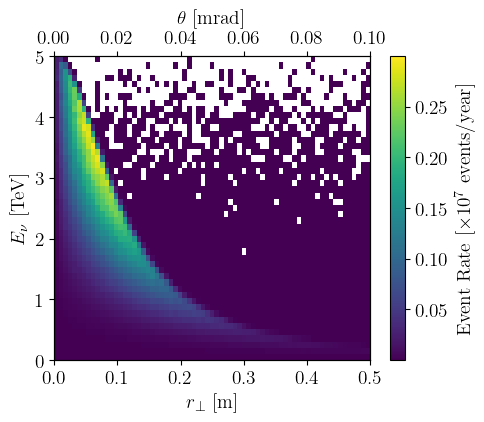

In [16]:
r_map_cm = 50   # benchmark detector face
ebins_fine = np.linspace(0, 5e3, 50)
r_edges_zoom = np.linspace(0.0, r_map_cm, 70)
hist, r_e, e_e = E_vs_radius_event_map(
    sims["ring"]["numubar_nobd"], "numubar", det_location, ebins_fine, r_edges_zoom
)
print(f"Total rate in map: {hist.sum():.3e} events / year")

fig, ax = pt.std_fig(figsize=(5, 4))

Z = hist.T / 1e7   # scale to 10^7 events/year
Z[Z <=0] = np.nan   # avoid log(0) in the color scale
im = ax.pcolormesh(r_e / 100, e_e / 1000, Z, cmap="viridis",)
ax.set_xlabel(r"$r_\perp$ [m]", fontsize=14)
ax.set_ylabel(r"$E_\nu$ [TeV]", fontsize=14)
cb = fig.colorbar(im, ax=ax)
ax.tick_params(labelsize=14)
cb.ax.tick_params(labelsize=14)
cb.set_label(r"Event Rate [$\times 10^7$ events/year]", size=14)
ax.set_xlim(0, r_map_cm / 1e2)

ax2 = ax.twiny()
ax2.set_xlim(0, r_map_cm / 1e2 * MRAD_PER_M)   # theta ~ rho / L_det
ax2.set_xlabel(r"$\theta$ [mrad]", fontsize=14)
ax2.tick_params(labelsize=14)

fig.savefig("plots/neutrino_energy_vs_radius_noBD.png", dpi=400, bbox_inches="tight")

Total rate in map: 4.217e+08 events / year


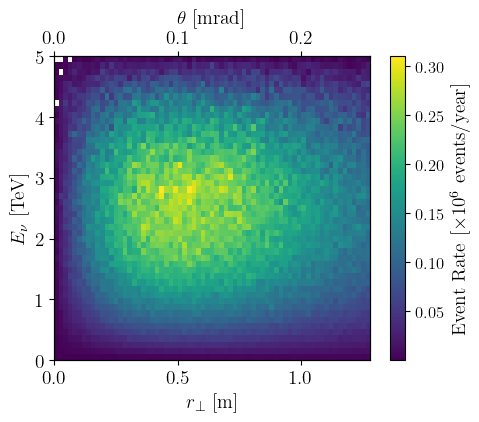

In [17]:
r_map_cm = det_radius   # benchmark detector face
ebins_fine = np.linspace(0, 5e3, 50)
r_edges_zoom = np.linspace(0.0, r_map_cm, 70)
hist, r_e, e_e = E_vs_radius_event_map(
    sims["ring"]["numubar"], "numubar", det_location, ebins_fine, r_edges_zoom
)
print(f"Total rate in map: {hist.sum():.3e} events / year")

fig, ax = pt.std_fig(figsize=(5, 4))

Z = hist.T / 1e6   # scale to 10^6 events/year
Z[Z <=0] = np.nan   # avoid log(0) in the color
im = ax.pcolormesh(r_e / 100, e_e / 1000, Z, cmap="viridis")
ax.set_xlabel(r"$r_\perp$ [m]", fontsize=14)
ax.set_ylabel(r"$E_\nu$ [TeV]", fontsize=14)
cb = fig.colorbar(im, ax=ax)
cb.ax.tick_params(labelsize=12)
ax.tick_params(labelsize=14)
cb.set_label(r"Event Rate [$\times 10^6$ events/year]", size=14)
ax.set_xlim(0, r_map_cm / 1e2)

ax2 = ax.twiny()
ax2.set_xlim(0, r_map_cm / 1e2 * MRAD_PER_M)   # theta ~ rho / L_det
ax2.set_xlabel(r"$\theta$ [mrad]", fontsize=14)
ax2.tick_params(labelsize=14)

fig.savefig("plots/neutrino_energy_vs_radius.png", dpi=400, bbox_inches="tight")

## 7. Transverse flux map (no-chicane lattice)

Neutrino hit positions on the $z = 1$ km detector plane for the no-chicane lattice,
colored by flux. Without the chicane the decays upstream of the IP paint an off-axis
stripe onto the detector plane.

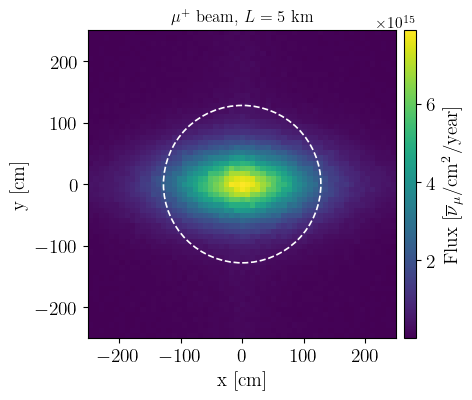

In [18]:
sim = sims["ring"]["numubar"]

det_vector = vector.array({"x": [0], "y": [0], "z": [det.dist]})   # benchmark detector plane
distances = det_vector - sim.pos
dotprod = distances.dot(sim.pnu.to_3D().unit())

# Where each neutrino crosses the z = z_det plane
lam = (det_vector["z"] - sim.pos["z"]) / sim.pnu["pz"]
x_hit = sim.pos["x"] + lam * sim.pnu["px"]
y_hit = sim.pos["y"] + lam * sim.pnu["py"]

in_acceptance = (dotprod > 0) & (sim.pnu["E"] > 0)
flux_weights = sim.weights.flatten()[in_acceptance] * bunches_per_year

# transverse range scaled to the 5 km plane, centred on the 2 m detector
x_bins = np.linspace(-250, 250, 60)
y_bins = np.linspace(-250, 250, 60)

fig, ax = plt.subplots(figsize=(5, 4))
counts, xedges, yedges, im = ax.hist2d(
    x_hit[in_acceptance], y_hit[in_acceptance],
    bins=(x_bins, y_bins),
    cmap="viridis",
    weights=flux_weights ,
    cmin=1,
)

# ax.contour(xedges[:-1], yedges[:-1], counts.T, levels=5, colors="black", linewidths=0.5)

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="4%", pad=0.08)
cbar = fig.colorbar(im, cax=cax)
cbar.set_label(r"Flux [$\overline{\nu}_\mu /$cm$^2$/year$]$", fontsize=14)
cbar.ax.tick_params(labelsize=14)


ax.add_patch(plt.Circle((0, 0), det_radius, fill=False, color="white",
                        lw=1.2, ls="--"))
ax.set_title(rf"$\mu^+$ beam, $L = {L_KM:.0f}$ km",
             fontsize=12)
ax.set_xlabel("x [cm]", fontsize=14)
ax.set_ylabel("y [cm]", fontsize=14)
ax.tick_params(labelsize=14)
ax.set_aspect("equal")
# ax.grid(True, alpha=0.3)

fig.savefig("plots/detector_flux_map_2d.png", dpi=400, bbox_inches="tight")

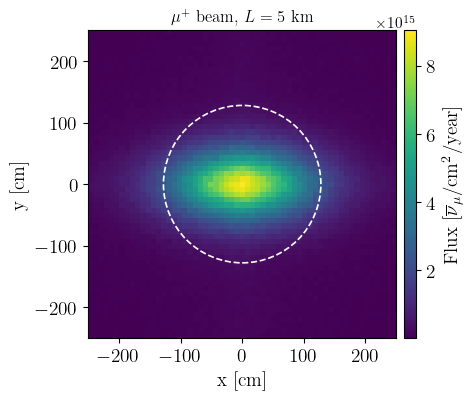

In [19]:
sim = sims["no_chicane"]["numubar"]

det_vector = vector.array({"x": [0], "y": [0], "z": [det.dist]})   # benchmark detector plane
distances = det_vector - sim.pos
dotprod = distances.dot(sim.pnu.to_3D().unit())

# Where each neutrino crosses the z = z_det plane
lam = (det_vector["z"] - sim.pos["z"]) / sim.pnu["pz"]
x_hit = sim.pos["x"] + lam * sim.pnu["px"]
y_hit = sim.pos["y"] + lam * sim.pnu["py"]

in_acceptance = (dotprod > 0) & (sim.pnu["E"] > 0)
flux_weights = sim.weights.flatten()[in_acceptance] * bunches_per_year

# transverse range scaled to the 5 km plane, centred on the 2 m detector
x_bins = np.linspace(-250, 250, 60)
y_bins = np.linspace(-250, 250, 60)

fig, ax = plt.subplots(figsize=(5, 4))
counts, xedges, yedges, im = ax.hist2d(
    x_hit[in_acceptance], y_hit[in_acceptance],
    bins=(x_bins, y_bins),
    cmap="viridis",
    weights=flux_weights ,
    cmin=1,
)

# ax.contour(xedges[:-1], yedges[:-1], counts.T, levels=5, colors="black", linewidths=0.5)

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="4%", pad=0.08)
cbar = fig.colorbar(im, cax=cax)
cbar.set_label(r"Flux [$\overline{\nu}_\mu /$cm$^2$/year$]$", fontsize=14)
cbar.ax.tick_params(labelsize=14)


ax.add_patch(plt.Circle((0, 0), det_radius, fill=False, color="white",
                        lw=1.2, ls="--"))
ax.set_title(rf"$\mu^+$ beam, $L = {L_KM:.0f}$ km",
             fontsize=12)
ax.set_xlabel("x [cm]", fontsize=14)
ax.set_ylabel("y [cm]", fontsize=14)
ax.tick_params(labelsize=14)
ax.set_aspect("equal")
# ax.grid(True, alpha=0.3)

fig.savefig("plots/detector_flux_map_2d_nochicane.png", dpi=400, bbox_inches="tight")

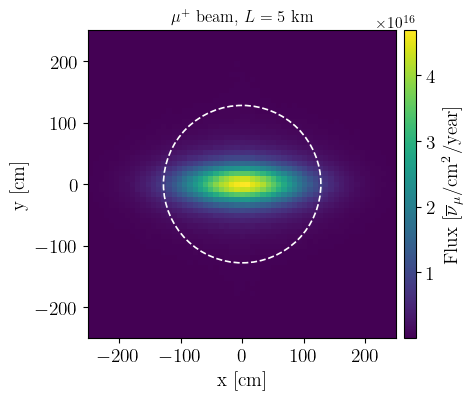

In [20]:
sim = sims["straight"]["numubar"]

det_vector = vector.array({"x": [0], "y": [0], "z": [det.dist]})   # benchmark detector plane
distances = det_vector - sim.pos
dotprod = distances.dot(sim.pnu.to_3D().unit())

# Where each neutrino crosses the z = z_det plane
lam = (det_vector["z"] - sim.pos["z"]) / sim.pnu["pz"]
x_hit = sim.pos["x"] + lam * sim.pnu["px"]
y_hit = sim.pos["y"] + lam * sim.pnu["py"]

in_acceptance = (dotprod > 0) & (sim.pnu["E"] > 0)
flux_weights = sim.weights.flatten()[in_acceptance] * bunches_per_year

# transverse range scaled to the 5 km plane, centred on the 2 m detector
x_bins = np.linspace(-250, 250, 60)
y_bins = np.linspace(-250, 250, 60)

fig, ax = plt.subplots(figsize=(5, 4))
counts, xedges, yedges, im = ax.hist2d(
    x_hit[in_acceptance], y_hit[in_acceptance],
    bins=(x_bins, y_bins),
    cmap="viridis",
    weights=flux_weights ,
    cmin=1,
)

# ax.contour(xedges[:-1], yedges[:-1], counts.T, levels=5, colors="black", linewidths=0.5)

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="4%", pad=0.08)
cbar = fig.colorbar(im, cax=cax)
cbar.set_label(r"Flux [$\overline{\nu}_\mu /$cm$^2$/year$]$", fontsize=14)
cbar.ax.tick_params(labelsize=14)


ax.add_patch(plt.Circle((0, 0), det_radius, fill=False, color="white",
                        lw=1.2, ls="--"))
ax.set_title(rf"$\mu^+$ beam, $L = {L_KM:.0f}$ km",
             fontsize=12)
ax.set_xlabel("x [cm]", fontsize=14)
ax.set_ylabel("y [cm]", fontsize=14)
ax.tick_params(labelsize=14)
ax.set_aspect("equal")
# ax.grid(True, alpha=0.3)

fig.savefig("plots/detector_flux_map_2d_straight.png", dpi=400, bbox_inches="tight")

## 8. Decay point vs hit position (nominal ring)

Where along the lattice ($s$, measured from the IP) the neutrinos reaching the detector
plane were produced, against their transverse hit coordinate, with the flux-weighted
marginal distribution on the right.

In [21]:
sim = sims["ring"]["numubar"]

z_det = det.dist   # cm (benchmark baseline)
det_vector = vector.array({"x": [0], "y": [0], "z": [z_det]})
distances = det_vector - sim.pos
dotprod = distances.dot(sim.pnu.to_3D().unit())

lam = (z_det - sim.pos["z"]) / sim.pnu["pz"]
x_hit = sim.pos["x"] + lam * sim.pnu["px"]
y_hit = sim.pos["y"] + lam * sim.pnu["py"]

# Keep every neutrino crossing the plane within 10 m of the axis
hit_radius = 20e2   # cm
in_acceptance = ((dotprod > 0) & (sim.pnu["E"] > 0)
                 & (np.sqrt(x_hit**2 + y_hit**2) < hit_radius))

# Decay point along the lattice, centered on the IP (midpoint of the covered section)
s_decay_m = (sim.s_in_turn[in_acceptance] - sim.s_in_turn.max() / 2) * 1e-2
flux_weights = sim.weights.flatten()[in_acceptance] * bunches_per_year

print(f"{in_acceptance.sum()} MC events within {hit_radius / 100:.0f} m of the axis")

2316942 MC events within 20 m of the axis


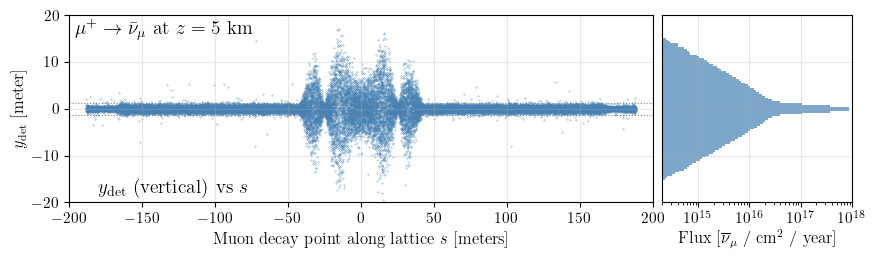

In [22]:
y_plot = y_hit[in_acceptance] * 1e-2   # m
x_max_m = hit_radius/1e2

fig = plt.figure(figsize=(9, 2.4))
gs = fig.add_gridspec(nrows=1, ncols=2, width_ratios=(4, 1.3), wspace=0.025)
ax_scatter = fig.add_subplot(gs[0, 0])
ax_hist = fig.add_subplot(gs[0, 1], sharey=ax_scatter)

# H, s_edges, y_edges = np.histogram2d(
#     s_decay_m,
#     y_plot,
#     bins=(180, 120),
#     weights=np.asarray(flux_weights),
# )

# H = H.T
# H[H <= 0] = np.nan
# cbar = fig.colorbar(mesh, ax=ax_scatter, pad=0.01)
# cbar.set_label(r"Flux-weighted density [$\bar{\nu}_\mu$ / year]", fontsize=12)
# cbar.ax.tick_params(labelsize=11)
# mesh = ax_scatter.pcolormesh(s_edges, y_edges, (H), cmap="viridis", shading="auto")
s_decay_m_thin = s_decay_m[::50]
y_plot_thin = y_plot[::50]
ax_scatter.scatter(s_decay_m_thin, y_plot_thin, s=0.05, color='steelblue', alpha=1)

ax_scatter.set_xlabel(r"Muon decay point along lattice $s$ [meters]", fontsize=12)
ax_scatter.set_ylabel(r"$y_{\rm det}$ [meter]", fontsize=12)
ax_scatter.annotate(r"$\mu^+ \to \bar{\nu}_\mu$ at $z=5$ km", xy=(0.01, 0.90),
                    xycoords="axes fraction", ha="left", fontsize=14)
ax_scatter.set_xlim(-200, 200)
ax_scatter.axhline(det_radius / 100, color="gray", ls=":", lw=0.8)
ax_scatter.axhline(-det_radius / 100, color="gray", ls=":", lw=0.8)
ax_scatter.set_ylim(-x_max_m, x_max_m)
ax_scatter.grid(True, alpha=0.3)

ax_hist.hist(y_plot, bins=100, range=(-x_max_m, x_max_m), weights=np.asarray(flux_weights),
             histtype="stepfilled", alpha=0.7, orientation="horizontal", color="steelblue")
ax_hist.set_xlabel(r"Flux [$\overline\nu_\mu$ / cm$^{2}$ / year]", fontsize=12)
ax_hist.set_xscale("log")
ax_hist.set_xlim(2e14, 1e18)
ax_hist.grid(True, alpha=0.3)
ax_hist.tick_params(axis="y", which="both", left=False, right=False,
                    labelleft=False, labelright=False)
ax_hist.set_xticks([1e15, 1e16, 1e17, 1e18])

ax_scatter.annotate(r"$y_{\rm det}$ (vertical) vs $s$", xy=(0.05, 0.13), xycoords="axes fraction",
                    fontsize=14, verticalalignment="top")

# fig.colorbar(mesh, ax=ax_scatter, pad=0.01, label=r"Flux-weighted density [$\bar{\nu}_\mu$ / year]")
fig.subplots_adjust(left=0.11, right=0.98, bottom=0.18, top=0.96)
fig.savefig("plots/yhits_vs_z_ring.png", dpi=300, bbox_inches="tight")

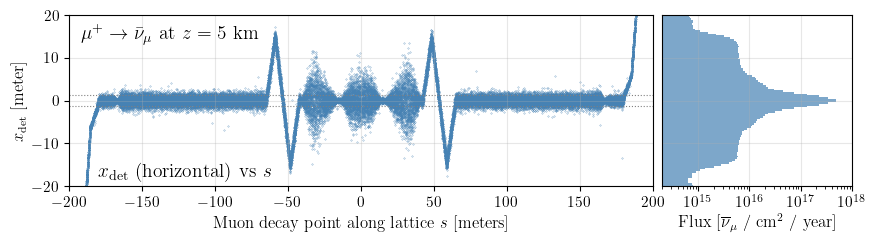

In [23]:
x_plot = x_hit[in_acceptance] * 1e-2   # m

fig = plt.figure(figsize=(9, 2.2))
gs = fig.add_gridspec(nrows=1, ncols=2, width_ratios=(4, 1.3), wspace=0.025)
ax_scatter = fig.add_subplot(gs[0, 0])
ax_hist = fig.add_subplot(gs[0, 1], sharey=ax_scatter)

# H, s_edges, x_edges = np.histogram2d(
#     s_decay_m, x_plot,
#     bins=(180, 120),
#     weights=np.asarray(flux_weights),
# )

# H = H.T
# H[H <= 0] = np.nan

# mesh = ax_scatter.pcolormesh(s_edges, x_edges, np.log10(H), cmap="viridis", shading="auto")
s_decay_m_thin = s_decay_m[::50]
x_plot_thin = x_plot[::50]
ax_scatter.scatter(s_decay_m_thin, x_plot_thin, s=0.05, color='steelblue', alpha=1)

ax_scatter.set_xlabel(r"Muon decay point along lattice $s$ [meters]", fontsize=12)
ax_scatter.set_ylabel(r"$x_{\rm det}$ [meter]", fontsize=12)
ax_scatter.annotate(r"$\mu^+ \to \bar{\nu}_\mu$ at $z=5$ km", xy=(0.02, 0.86),
                    xycoords="axes fraction", ha="left", fontsize=14)
ax_scatter.annotate(r"$x_{\rm det}$ (horizontal) vs $s$", xy=(0.05, 0.14), xycoords="axes fraction",
                    fontsize=14, verticalalignment="top")
ax_scatter.set_xlim(-200, 200)
ax_scatter.axhline(det_radius / 100, color="gray", ls=":", lw=0.8)
ax_scatter.axhline(-det_radius / 100, color="gray", ls=":", lw=0.8)
ax_scatter.set_ylim(-x_max_m, x_max_m)  # m
ax_scatter.grid(True, alpha=0.3)

ax_hist.hist(x_plot, bins=100, range=(-x_max_m, x_max_m), weights=np.asarray(flux_weights), color="steelblue",
             histtype="stepfilled", alpha=0.7, orientation="horizontal")
ax_hist.set_xlabel(r"Flux [$\overline\nu_\mu$ / cm$^{2}$ / year]", fontsize=12)
ax_hist.set_xscale("log")
ax_hist.set_xlim(2e14, 1e18)
ax_hist.grid(True, alpha=0.3)
ax_hist.tick_params(axis="y", which="both", left=False, right=False,
                    labelleft=False, labelright=False)
ax_hist.set_xticks([1e15, 1e16, 1e17, 1e18])


# fig.colorbar(mesh, ax=ax_scatter, pad=0.01, label=r"Flux-weighted density [$\bar{\nu}_\mu$ / year]")
fig.subplots_adjust(left=0.11, right=0.98, bottom=0.18, top=0.96)
fig.savefig("plots/xhits_vs_z_ring.png", dpi=300, bbox_inches="tight")

## 7. How far away can the detector be?

The detector face subtends a solid angle that shrinks as $1/L^2$, while the
neutrino beam has a fixed angular width set by the muon divergence. Where those
two effects cross determines how much rate you lose by moving further out.

This section scans the front face from $250$~m to $50$~km, holding the detector
at its *physical* 5 km size. That last point matters: the benchmark aperture is
defined as $R = n_\sigma\sigma_{\rm spot} + z\tan\theta_{\rm acc}$ with
$\sigma_{\rm spot}\propto L$, so simply reloading it at a new distance would
rebuild it larger. Rescaling $n_\sigma$ as $1/L$ keeps the physical aperture
fixed and changes only the distance -- one detector, moved.

Three beam models are compared against the real lattice, so you can see how much
of the answer depends on the optics rather than on geometry alone.

In [24]:
N_EVALS = 1e5
D_SCAN = np.geomspace(250e2, 50e5, 18)        # 250 m -> 50 km, front face


def ring_with_divergence(sx, sy):
    """The ring with its transverse divergences replaced by constant Gaussians
    of width (sx, sy) [rad]. Orbit, envelope, dispersion and momentum spread are
    left untouched, so this isolates the effect of the divergence alone."""
    r = mint.lattices.load("mc_10tev_hybrid_v06")
    r.beamdiv_x = lambda u, _s=sx: np.full(np.shape(u), _s)
    r.beamdiv_y = lambda u, _s=sy: np.full(np.shape(u), _s)
    return r


def mu_plus_beam(ring=None, beam_dynamics=True, n_evals=N_EVALS):
    """A mu+ beam: the numubar simulation plus its exact nue reweighting."""
    ring_, s_mb, ipy = mint.beams.standard_beam(
        nuflavor="numubar", direction="clockwise", n_evals=n_evals,
        beam_dynamics=beam_dynamics, ring=ring)
    s_e = s_mb.reweighted_copy(nuflavor="nue")
    s_e.place_muons_on_lattice(lattice=ring_, direction="clockwise")
    return s_mb, s_e, ipy


def rate_vs_distance(s_mb, s_e, ipy_, D_scan=D_SCAN):
    """Total nu interactions/yr in the signal volume vs front-face distance,
    with the detector held at its physical 5 km size."""
    out = []
    for D in D_scan:
        det_D = mint.detectors.load("benchmark_5km", dist=D,
                                    n_sigma=2.5 * 5e5 / D)
        tot = 0.0
        for s_, fl in ((s_mb, "numubar"), (s_e, "nue")):
            tot += det_D.signal_interactions(s_, nuflavor=fl, sign=+1,
                                             exposure=ipy_)["total"]
        out.append(tot)
    return np.array(out)


DIVERGENCE_MODELS = [
    ("lattice", None, True),
    (r"$\sigma_{px}=\sigma_{py}=0.1$ mrad",
     ring_with_divergence(1.2e-4, 1.2e-4), True),
    (r"$\sigma_{px}=0.08$, $\sigma_{py}=0.2$ mrad",
     ring_with_divergence(0.8e-4, 2.0e-4), True),
    ("no beam dynamics", None, False),
]

rates_vs_D = {}
for label, ring_model, bd in DIVERGENCE_MODELS:
    rates_vs_D[label] = rate_vs_distance(*mu_plus_beam(ring_model, bd))
    print(f"{label[:52]:54s} {rates_vs_D[label][0]:.3e} -> "
          f"{rates_vs_D[label][-1]:.3e}")

/Users/mhostert/Repos/MINT/mint/MuC.py:491: UserWarning: The lattice covers only 14.6% of the machine (arc length 1.465e+05 cm of total_circumference 1e+06 cm). Muon decays are placed on the covered section only; muon travel times account for propagation through the full machine.
  warnings.warn(


lattice                                                1.845e+09 -> 4.453e+07


$\sigma_{px}=\sigma_{py}=0.1$ mrad                     1.839e+09 -> 4.597e+07


$\sigma_{px}=0.08$, $\sigma_{py}=0.2$ mrad             1.864e+09 -> 4.117e+07


/Users/mhostert/Repos/MINT/mint/MuC.py:491: UserWarning: The lattice covers only 14.6% of the machine (arc length 1.465e+05 cm of total_circumference 1e+06 cm). Muon decays are placed on the covered section only; muon travel times account for propagation through the full machine.
  warnings.warn(


no beam dynamics                                       1.864e+09 -> 1.159e+09



ratio to the real lattice at 5.6 km:
   $\sigma_{px}=\sigma_{py}=0.1$ mrad               1.293
   $\sigma_{px}=0.08$, $\sigma_{py}=0.2$ mrad       1.178


/var/folders/dl/ccbsfs591r1fhgcws28m8xy40000gn/T/ipykernel_70858/806149754.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


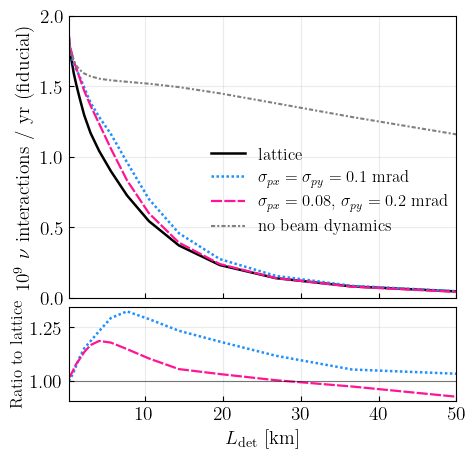

In [25]:
STYLE = [("black", "-", 1.8), ("dodgerblue", (0, (1, 1)), 1.8),
         ("deeppink", (0, (5, 1)), 1.6), ("grey", (0, (2, 1, 1, 1)), 1.5)]

fig, (ax, ax_ratio) = plt.subplots(
    2, 1, figsize=(5, 5), sharex=True,
    gridspec_kw={"hspace": 0.05, "height_ratios": [3, 1]})

for (label, *_), (c, ls, lw) in zip(DIVERGENCE_MODELS, STYLE):
    ax.plot(D_SCAN / 1e5, rates_vs_D[label] / 1e9, color=c, ls=ls, lw=lw,
            label=label)

lattice_rate = rates_vs_D["lattice"]
for (label, *_), (c, ls, lw) in zip(DIVERGENCE_MODELS[1:3], STYLE[1:3]):
    ax_ratio.plot(D_SCAN / 1e5, rates_vs_D[label] / lattice_rate,
                  color=c, ls=ls, lw=lw, label=label)

ax.set_ylim(0, 2)
ax.set_ylabel(r"$10^9$ $\nu$ interactions / yr (fiducial)", fontsize=14)
ax.tick_params(axis="both", which="both", labelsize=14, direction="in")
ax.set_xlim(D_SCAN[0] / 1e5, D_SCAN[-1] / 1e5)
ax.grid(which="both", alpha=0.25)
ax.legend(frameon=False, fontsize=12, loc=(0.35, 0.2))

ax_ratio.set_xlabel(r"$L_{\rm det}$ [km]", fontsize=14)
ax_ratio.set_ylabel(r"\noindent \,\, Ratio to lattice", fontsize=12)
ax_ratio.tick_params(axis="both", which="both", labelsize=14, direction="in")
ax_ratio.grid(which="both", alpha=0.25)
ax_ratio.axhline(y=1, color="black", ls="-", lw=0.8, alpha=0.5)

fig.tight_layout()
fig.savefig("plots/nu_rate_vs_distance.pdf", dpi=300, bbox_inches="tight")

i5 = int(np.argmin(abs(D_SCAN - 5e5)))
print(f"\nratio to the real lattice at {D_SCAN[i5]/1e5:.1f} km:")
for lab, *_ in DIVERGENCE_MODELS[1:3]:
    print(f"   {lab[:46]:48s} {rates_vs_D[lab][i5]/lattice_rate[i5]:.3f}")

Out to a few hundred metres the fixed $1.28$~m face subtends far more than the
decay cone, so every model collects the whole flux and the divergence is
irrelevant. The curves separate once $R/L$ falls to the scale of the divergence.

Both Gaussian models sit **above** the real lattice at large $L_{\rm det}$,
and that gap is the non-Gaussian tail. A Gaussian of the right core width still
puts too little flux at large angle, so it over-predicts what a distant detector
collects. If you are sizing a detector from an assumed divergence rather than
from a lattice, this is the direction the error runs.

Turning the beam dynamics off entirely is the ceiling: with the beam on the
ideal closed orbit the cone is as narrow as $1/\gamma$ allows, and the fixed
face keeps collecting everything out to the largest distances shown.

### Fitting an equivalent Gaussian beam

The curves above use divergences that were *assumed*, not measured. A fairer
question is: what constant Gaussian divergence best mimics the real lattice over
the whole range of distances?

Fit it. Take one bin per km from 1 to 50 km, and choose $\sigma$ to minimise the
RMS of $\log(\text{rate}_\text{Gaussian}/\text{rate}_\text{lattice})$ across the
bins. The log makes over- and under-shooting count equally, and the ratio is the
quantity that matters -- we want a Gaussian that tracks the lattice everywhere,
not one that matches at a single distance and drifts away from it.

One vegas sample is generated and re-placed on each trial lattice, so a trial
costs a placement rather than a fresh simulation. The random seed is reset
before every placement: without that the objective carries Monte-Carlo noise and
the optimiser chases the noise instead of the parameters.

In [26]:
import warnings

from scipy.optimize import minimize_scalar, minimize

# Each trial re-places the muons, and MINT warns every time that the lattice
# covers only part of the machine. That is expected here, and dozens of copies
# of it would bury the fit output.
warnings.filterwarnings("ignore", message=".*lattice covers only.*")

D_FIT = np.arange(1, 51, 1.0) * 1e5          # one bin per km, 1 to 50 km
SEED = 20250816

# one generation, reused for every trial
np.random.seed(SEED)
_ring0, _s_mb, _ipy = mint.beams.standard_beam("numubar", n_evals=6e4)
_s_e = _s_mb.reweighted_copy(nuflavor="nue")


def rate_curve(ring):
    """Interactions/yr vs distance, for a given divergence model."""
    for s in (_s_mb, _s_e):
        np.random.seed(SEED)                 # deterministic objective
        s.place_muons_on_lattice(lattice=ring, direction="clockwise")
    out = []
    for D in D_FIT:
        det_D = mint.detectors.load("benchmark_5km", dist=D, n_sigma=2.5 * 5e5 / D)
        out.append(sum(det_D.signal_interactions(s, nuflavor=f, sign=+1,
                                                 exposure=_ipy)["total"]
                       for s, f in ((_s_mb, "numubar"), (_s_e, "nue"))))
    return np.array(out)


lattice_curve = rate_curve(_ring0)


def rms_log_ratio(sx, sy):
    r = rate_curve(ring_with_divergence(sx, sy)) / lattice_curve
    return float(np.sqrt(np.mean(np.log(np.maximum(r, 1e-12)) ** 2)))


# one isotropic width
_r1 = minimize_scalar(lambda ls: rms_log_ratio(np.exp(ls), np.exp(ls)),
                      bounds=(np.log(2e-5), np.log(5e-4)), method="bounded",
                      options={"xatol": 1e-3})
SIG_ISO = float(np.exp(_r1.x))

# independent horizontal and vertical widths
_r2 = minimize(lambda p: rms_log_ratio(np.exp(p[0]), np.exp(p[1])),
               x0=[np.log(SIG_ISO)] * 2, method="Nelder-Mead",
               options={"xatol": 2e-3, "fatol": 1e-4, "maxiter": 60})
SIG_X, SIG_Y = (float(v) for v in np.exp(_r2.x))

print(f"1D  sigma            = {SIG_ISO*1e3:.3f} mrad          RMS = {_r1.fun:.4f}")
print(f"2D  sigma_x, sigma_y = {SIG_X*1e3:.3f}, {SIG_Y*1e3:.3f} mrad   RMS = {_r2.fun:.4f}")
print()
print(f"{'model':22s}{'RMS':>8s}   ratio at 1 / 10 / 25 / 50 km")
for lbl, a, b in (("assumed 0.1/0.1", 1e-4, 1e-4),
                  ("assumed 0.08/0.2", 0.8e-4, 2e-4),
                  ("fitted isotropic", SIG_ISO, SIG_ISO),
                  ("fitted anisotropic", SIG_X, SIG_Y)):
    r = rate_curve(ring_with_divergence(a, b)) / lattice_curve
    print(f"{lbl:22s}{np.sqrt(np.mean(np.log(r)**2)):8.4f}   "
          f"{r[0]:.3f}  {r[9]:.3f}  {r[24]:.3f}  {r[49]:.3f}")

1D  sigma            = 0.128 mrad          RMS = 0.1053
2D  sigma_x, sigma_y = 0.058, 0.248 mrad   RMS = 0.0273

model                      RMS   ratio at 1 / 10 / 25 / 50 km


assumed 0.1/0.1         0.4260   1.050  1.565  1.561  1.537


assumed 0.08/0.2        0.0723   1.045  1.103  0.967  0.964


fitted isotropic        0.1053   1.050  1.216  0.989  0.938


fitted anisotropic      0.0273   1.036  0.994  0.986  1.023


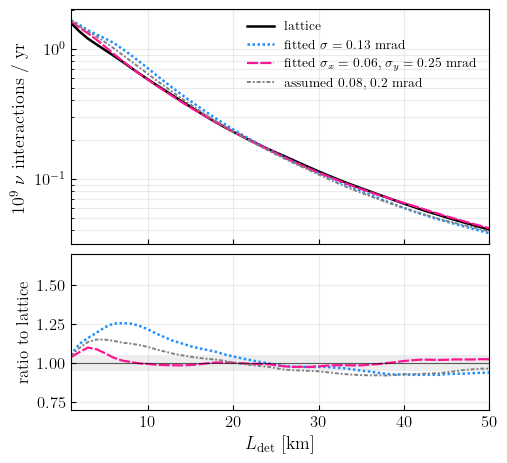

In [27]:
FITTED = [
    ("lattice", None, "black", "-", 1.8),
    (rf"fitted $\sigma={SIG_ISO*1e3:.2f}$ mrad", (SIG_ISO, SIG_ISO),
     "dodgerblue", (0, (1, 1)), 1.8),
    (rf"fitted $\sigma_x={SIG_X*1e3:.2f}$, $\sigma_y={SIG_Y*1e3:.2f}$ mrad",
     (SIG_X, SIG_Y), "deeppink", (0, (5, 1)), 1.6),
    (r"assumed $0.08$, $0.2$ mrad", (0.8e-4, 2.0e-4), "grey", (0, (2, 1, 1, 1)), 1.4),
]

curves = {}
for lbl, pars, *_ in FITTED:
    curves[lbl] = lattice_curve if pars is None else rate_curve(ring_with_divergence(*pars))

fig, (ax, axr) = plt.subplots(2, 1, figsize=(5.4, 5.2), sharex=True,
                              gridspec_kw={"hspace": 0.05, "height_ratios": [3, 2]})
for lbl, _, c, ls, lw in FITTED:
    ax.plot(D_FIT / 1e5, curves[lbl] / 1e9, color=c, ls=ls, lw=lw, label=lbl)
    if lbl != "lattice":
        axr.plot(D_FIT / 1e5, curves[lbl] / lattice_curve, color=c, ls=ls, lw=lw)

ax.set_yscale("log")
ax.set_ylabel(r"$10^9$ $\nu$ interactions / yr", fontsize=13)
ax.legend(frameon=False, fontsize=9.5)
ax.tick_params(which="both", direction="in", labelsize=12)
ax.grid(which="both", alpha=0.25)

axr.axhline(1.0, color="black", lw=0.8, alpha=0.6)
axr.fill_between([1, 50], 0.95, 1.05, color="black", alpha=0.07, lw=0)
axr.set_ylim(0.7, 1.7)
axr.set_xlim(1, 50)
axr.set_xlabel(r"$L_{\rm det}$ [km]", fontsize=13)
axr.set_ylabel("ratio to lattice", fontsize=12)
axr.tick_params(which="both", direction="in", labelsize=12)
axr.grid(which="both", alpha=0.25)

fig.subplots_adjust(hspace=0.05)
fig.savefig("plots/nu_rate_gaussian_fit.pdf", dpi=300, bbox_inches="tight")

The fitted anisotropic pair tracks the lattice to a few percent across the whole
1--50 km range, three to four times better in RMS than the isotropic fit. One
width cannot do as well at any value: a single number cannot reproduce two
different projections.

**The fit determines the pair of widths, not which plane is which.** Running the
optimiser twice returns $\{0.25, 0.06\}$ mrad with the labels swapped, at
essentially the same RMS, and evaluating the two assignments directly confirms
they are nearly degenerate. That is not a failure of the optimiser -- it is the
geometry. The rate is collected through a *circular* aperture, so it responds to
the total solid angle the beam subtends and is almost blind to how the width is
divided between horizontal and vertical.

So quote the result as an unordered pair. Deciding which plane is the wide one
needs the transverse spot shape rather than the integrated rate: the beam-optics
notebook shows the divergence plateau along the straight is larger in $x$ than in
$y$, which settles it in a way this fit cannot.

The practical lesson is the same one the assumed values illustrate. The
$0.1$ mrad isotropic guess is off by 50% at 10--50 km, while $0.08$, $0.2$ mrad
does respectably -- but its respectable RMS comes from having roughly the right
*pair*, not from having the planes right.